# Driver Feedback Analysis

## Domain-Specific Entity Extraction Using GLiNER

### Overview
This notebook performs Named Entity Recognition (NER) on passenger feedback using GLiNER. The extracted entities provide structured information such as driver behaviors, vehicle conditions, locations, traffic conditions, and safety issues, which can be used for exploratory analysis and future dashboard visualizations.

## Import libraries

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
import pandas as pd

from utils.data_loader import (
    load_processed_feedback,
    save_processed_feedback
)
from utils.config import PROCESSED_DATA_DIR
from utils.constants import NER_LABELS
from utils.ner_utils import (
    load_gliner_model,
    extract_entities_dataframe,
    flatten_entities
)
from utils.visualization import (
    plot_entity_distribution,
    plot_top_entities
)

## Load Dataset

In [3]:
df = load_processed_feedback()

df.head()

,trip_id,timestamp,rating,feedback_text,sentiment,clean_text,character_count,word_count,average_word_length
0,TR000001,2025-12-26 12:44:39,1.0,I completed running New York Marathon requeste...,negative,I completed running New York Marathon requeste...,2259,359,5.295265
1,TR000002,2025-12-28 03:07:09,1.0,My appointment time auto repairs required earl...,negative,My appointment time auto repairs required earl...,1147,169,5.792899
2,TR000003,2025-04-02 22:33:06,1.0,Whether I using Uber ride service Uber Eats or...,negative,Whether I using Uber ride service Uber Eats or...,661,99,5.686869
3,TR000004,2025-12-02 18:42:33,1.0,Why hard understand I trying retrieve Uber cab...,negative,Why hard understand I trying retrieve Uber cab...,445,74,5.027027
4,TR000005,2025-03-05 02:37:34,1.0,I South Beach FL I staying major hotel ordered...,negative,I South Beach FL I staying major hotel ordered...,304,55,4.545455


## Inspect Dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   trip_id              1344 non-null   str    
 1   timestamp            1344 non-null   str    
 2   rating               1344 non-null   float64
 3   feedback_text        1344 non-null   str    
 4   sentiment            1344 non-null   str    
 5   clean_text           1344 non-null   str    
 6   character_count      1344 non-null   int64  
 7   word_count           1344 non-null   int64  
 8   average_word_length  1344 non-null   float64
dtypes: float64(2), int64(2), str(5)
memory usage: 1.2 MB


In [5]:
df.describe(include="all")

,trip_id,timestamp,rating,feedback_text,sentiment,clean_text,character_count,word_count,average_word_length
count,1344,1344,1344.000000,1344,1344,1344,1344.000000,1344.000000,1344.000000
unique,1344,1344,NaN,1342,3,1342,NaN,NaN,NaN
top,TR000001,2025-12-26 12:44:39,NaN,I use Uber occasions car needed repair I used ...,negative,I use Uber occasions car needed repair I used ...,NaN,NaN,NaN
freq,1,1,NaN,2,1083,2,NaN,NaN,NaN
mean,NaN,NaN,1.627232,NaN,NaN,NaN,432.390625,70.798363,5.123091
std,NaN,NaN,1.296149,NaN,NaN,NaN,425.129594,68.511405,0.529118
min,NaN,NaN,1.000000,NaN,NaN,NaN,6.000000,2.000000,2.500000
25%,NaN,NaN,1.000000,NaN,NaN,NaN,171.750000,28.000000,4.785714
50%,NaN,NaN,1.000000,NaN,NaN,NaN,307.500000,51.000000,5.086957
75%,NaN,NaN,1.000000,NaN,NaN,NaN,554.250000,92.000000,5.420263


In [6]:
df.shape

(1344, 9)

## Load GLiNER

In [7]:
model = load_gliner_model()

/home/melbert-bnn/Melbert/OJT/passenger-feedback-analysis/.venv/lib/python3.13/site-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

## Define NER Labels

In [8]:
NER_LABELS

['driver behavior',
 'driving quality',
 'safety issue',
 'vehicle condition',
 'cleanliness',
 'customer service',
 'communication',
 'punctuality',
 'traffic condition',
 'navigation issue',
 'payment issue',
 'fare issue',
 'pickup issue',
 'dropoff issue',
 'ride comfort']

## Extract Entities

In [9]:
feedback = extract_entities_dataframe(
    dataframe=df,
    text_column="clean_text",
    model=model,
    labels=NER_LABELS
)

feedback.head()

/home/melbert-bnn/Melbert/OJT/passenger-feedback-analysis/.venv/lib/python3.13/site-packages/gliner/data_processing/processor.py:417: UserWarning: Sentence of length 577 has been truncated to 384
  batch = [self.preprocess_example(b["tokenized_text"], b[key], class_to_ids) for b in batch_list]
/home/melbert-bnn/Melbert/OJT/passenger-feedback-analysis/.venv/lib/python3.13/site-packages/gliner/data_processing/processor.py:417: UserWarning: Sentence of length 474 has been truncated to 384
  batch = [self.preprocess_example(b["tokenized_text"], b[key], class_to_ids) for b in batch_list]
/home/melbert-bnn/Melbert/OJT/passenger-feedback-analysis/.venv/lib/python3.13/site-packages/gliner/data_processing/processor.py:417: UserWarning: Sentence of length 556 has been truncated to 384
  batch = [self.preprocess_example(b["tokenized_text"], b[key], class_to_ids) for b in batch_list]
/home/melbert-bnn/Melbert/OJT/passenger-feedback-analysis/.venv/lib/python3.13/site-packages/gliner/data_processing

,trip_id,timestamp,rating,feedback_text,sentiment,clean_text,character_count,word_count,average_word_length,entities
0,TR000001,2025-12-26 12:44:39,1.0,I completed running New York Marathon requeste...,negative,I completed running New York Marathon requeste...,2259,359,5.295265,"[{'start': 48, 'end': 52, 'text': 'Uber', 'lab..."
1,TR000002,2025-12-28 03:07:09,1.0,My appointment time auto repairs required earl...,negative,My appointment time auto repairs required earl...,1147,169,5.792899,[]
2,TR000003,2025-04-02 22:33:06,1.0,Whether I using Uber ride service Uber Eats or...,negative,Whether I using Uber ride service Uber Eats or...,661,99,5.686869,"[{'start': 34, 'end': 43, 'text': 'Uber Eats',..."
3,TR000004,2025-12-02 18:42:33,1.0,Why hard understand I trying retrieve Uber cab...,negative,Why hard understand I trying retrieve Uber cab...,445,74,5.027027,"[{'start': 38, 'end': 46, 'text': 'Uber cab', ..."
4,TR000005,2025-03-05 02:37:34,1.0,I South Beach FL I staying major hotel ordered...,negative,I South Beach FL I staying major hotel ordered...,304,55,4.545455,"[{'start': 47, 'end': 51, 'text': 'Uber', 'lab..."


## Flatten Entities

In [10]:
entity_df = flatten_entities(feedback)

entity_df.head()

,feedback,entity,label,score
0,I completed running New York Marathon requeste...,Uber,customer service,0.643894
1,I completed running New York Marathon requeste...,Uber,customer service,0.776482
2,I completed running New York Marathon requeste...,safety,vehicle condition,0.547477
3,I completed running New York Marathon requeste...,Uber,customer service,0.803787
4,I completed running New York Marathon requeste...,Lyft,customer service,0.684012


## Exploratory Data Analysis on Entities

In [11]:
entity_df["label"].value_counts()

label
customer service     2610
communication         281
traffic condition      90
driver behavior        66
cleanliness            62
vehicle condition      55
payment issue          46
punctuality            33
driving quality        20
safety issue           19
fare issue             16
ride comfort            6
navigation issue        5
pickup issue            4
dropoff issue           2
Name: count, dtype: int64

In [12]:
entity_df["entity"].value_counts().head(20)

entity
Uber                     1401
uber                      193
UBER                      148
customer service          130
email                     120
Lyft                       42
app                        29
traffic                    26
support                    25
emails                     23
Uber driver                22
customer support           21
Uber customer service      20
Uber app                   16
UberX                      15
Uber Support               12
customer care              11
contact                    11
rude                       11
service                    10
Name: count, dtype: int64

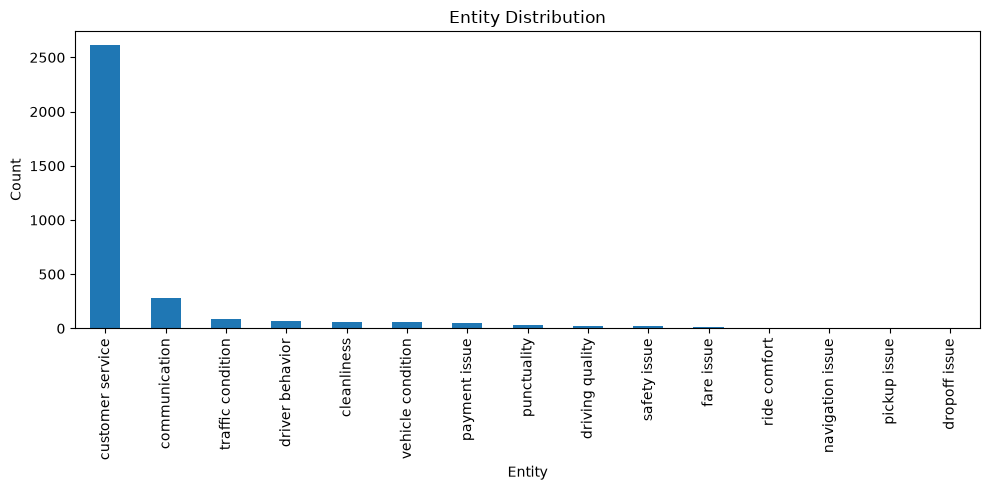

In [13]:
fig = plot_entity_distribution(entity_df)

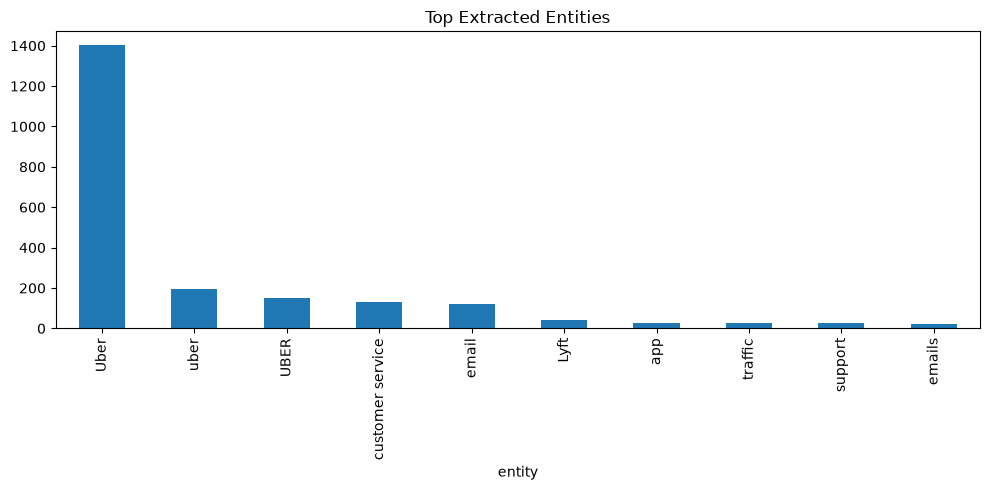

In [14]:
fig = plot_top_entities(entity_df)

## Save Dataset

In [15]:
save_processed_feedback(entity_df, "overall_entity.csv")

PosixPath('/home/melbert-bnn/Melbert/OJT/passenger-feedback-analysis/data/processed/overall_entity.csv')

In [16]:
feedback_with_entities = entity_df[["feedback", "entity"]]
save_processed_feedback(feedback_with_entities, "entity_feedback.csv")

PosixPath('/home/melbert-bnn/Melbert/OJT/passenger-feedback-analysis/data/processed/entity_feedback.csv')